# Session 9.2 — Data Prep: Handling Messy Data
### Advanced Cleaning for Machine Learning

> **Continuing from:** Session 9.1 — The ML Workflow & Habits (Problem framing, Features vs Labels, Train/Val/Test split, Baselines)
> **Dataset:** Used Car Prices (CarDekho — 15,600+ rows)
> **Duration:** ~1.5 hours
> **Style:** Teach first, practice later
> **Goal:** Take a real-world messy dataset and make it ML-ready

## What We've Covered So Far

| Session | Topics |
|---|---|
| 1.1–1.3 | AI Landscape, Lab Setup, Developer Workflow (CLI, Git) |
| 2.1–2.3 | Python Basics, Conditionals, Loops |
| 3.1–3.3 | Functions, Data Collections, File I/O |
| 4.1–4.3 | NumPy, Multidimensional Arrays, JSON |
| 5.1–5.3 | Pandas: DataFrames, Selection/Filtering, Cleaning/GroupBy |
| 6.1–6.3 | SQL: Tables, Querying, JOINs |
| 7.1–7.3 | Matplotlib, Plotly, EDA Checklist |
| 8.1–8.3 | APIs, API Security, EDA Workshop |
| 9.1 | ML Workflow: Problem Framing, Features vs Labels, Train/Val/Test Split, Baselines |

---

## The Story

You just got hired as a junior data scientist at **CarDekho** — India's biggest used car marketplace. Your manager walks in and says:

> *"We want to build a model that predicts the selling price of a used car based on its features — brand, age, mileage, fuel type, etc. The data team pulled 15,000+ records from our database, but... it's messy. Really messy. Missing values, typos, inconsistent formatting — the usual. Clean it up and get it ML-ready. You have until end of day."*

By the end of this session, you'll know exactly how to handle every kind of mess in real-world data. And you'll have a clean, ML-ready dataset to show for it.

---

## The Data Prep Pipeline

Remember this from our checklist? Today we're going deep into each step.

```
Raw Messy Data
    ↓
Step 1: Explore & Understand the Mess
    ↓
Step 2: Fix Text Issues (typos, casing, whitespace)
    ↓
Step 3: Handle Missing Values (drop vs impute)
    ↓
Step 4: Remove Duplicates
    ↓
Step 5: Handle Outliers
    ↓
Step 6: Encode Categorical Variables
    ↓
Step 7: Scale & Normalize Numerical Features
    ↓
Clean ML-Ready Data ✅
```

> 💡 **Key Idea**: The order matters! You clean text issues BEFORE handling missing values (otherwise you might count "Petrol" and "petrol" as different categories). You handle missing values BEFORE encoding (otherwise NaN gets encoded as a category). You split BEFORE scaling (to avoid data leakage).

Let's load the data and see what we're dealing with.

---

## Step 0: Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

---

## Step 1: Explore & Understand the Mess

Before you fix anything, you need to **understand what's broken**. This is like a doctor examining a patient before prescribing medicine — you don't just start treating random symptoms.

### 1.1 — Load and First Look

In [3]:
# Load the messy dataset
df = pd.read_csv('used_cars_messy.csv')

print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (15661, 14)

First 5 rows:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0


### 1.2 — The Health Check: `.info()`

This is your most important diagnostic tool. It tells you:
- How many non-null values each column has (reveals missing data)
- The data type of each column (reveals type mismatches)
- Memory usage

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


**What to look for:**

| What You See | What It Means | Action Needed |
|---|---|---|
| Non-Null count < total rows | Missing values | Impute or drop |
| `object` dtype on a numeric column | Numbers stored as strings | Parse/convert |
| A column like `Unnamed: 0` | Leftover index from CSV export | Drop it |
| Very few non-null in a column | Mostly empty column | Consider dropping entirely |

Let's check the missing values more precisely:

In [5]:
# Missing values — count and percentage
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(1)
})
missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
engine,1869,11.9
mileage,1285,8.2
max_power,799,5.1
seats,443,2.8
selling_price,158,1.0


### 1.3 — Check for Duplicates

In [6]:
# How many exact duplicate rows?
print(f"Exact duplicate rows: {df.duplicated().sum()}")

# Let's see a few duplicates
duplicates = df[df.duplicated(keep=False)].sort_values('car_name')
print(f"\nSample duplicates:")
duplicates.head(10)

Exact duplicate rows: 169

Sample duplicates:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9347,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
5920,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
13398,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
3642,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
867,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
8441,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
4958,11969,BMW X5,BMW,X5,7,68000,Dealer,Diesel,Automatic,11.7,2993.0,245.00,5.0,3200000.0
3709,11969,BMW X5,BMW,X5,7,68000,Dealer,Diesel,Automatic,11.7,2993.0,245.00,5.0,3200000.0
4973,7216,Datsun GO,Datsun,GO,4,23142,Dealer,Petrol,Manual,NaN,1198.0,67.00,5.0,360000.0
11616,7216,Datsun GO,Datsun,GO,4,23142,Dealer,Petrol,Manual,NaN,1198.0,67.00,5.0,360000.0


### 1.4 — Check Categorical Columns for Messiness

This is where real-world data gets ugly. Let's check what the categorical columns actually contain:

In [7]:
# Check unique values in categorical columns
cat_cols = ['brand', 'seller_type', 'fuel_type', 'transmission_type']

for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"\n{col} ({len(unique_vals)} unique values):")
    print(sorted(unique_vals))


brand (80 unique values):
[' Audi', ' Audi ', ' BMW', ' BMW ', ' Datsun', ' Datsun ', ' Ferrari ', ' Ford', ' Ford ', ' Honda', ' Honda ', ' Hyundai', ' Hyundai ', ' ISUZU ', ' Land Rover', ' MG ', ' Mahindra', ' Mahindra ', ' Maruti', ' Maruti ', ' Mercedes-AMG ', ' Mercedes-Benz ', ' Mini ', ' Nissan ', ' Porsche', ' Renault', ' Renault ', ' Skoda', ' Skoda ', ' Tata', ' Tata ', ' Toyota', ' Toyota ', ' Volkswagen', ' Volkswagen ', 'Audi', 'Audi ', 'BMW', 'BMW ', 'Bentley', 'Datsun', 'Datsun ', 'Force', 'Ford', 'Ford ', 'Honda', 'Honda ', 'Hyundai', 'Hyundai ', 'ISUZU', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'MG', 'Mahindra', 'Mahindra ', 'Maruti', 'Maruti ', 'Maserati', 'Mercedes-Benz', 'Mercedes-Benz ', 'Mini', 'Nissan', 'Porsche', 'Renault', 'Renault ', 'Rolls-Royce', 'Skoda', 'Skoda ', 'Tata', 'Tata ', 'Toyota', 'Toyota ', 'Volkswagen', 'Volkswagen ', 'Volvo', 'Volvo ']

seller_type (9 unique values):
['DEALER', 'Dealer', 'Delaer', 'Individual', 'Individuall', 

**Yikes.** Look at that mess:

- `fuel_type` has 14 "unique" values — but there should only be 5 (Petrol, Diesel, CNG, LPG, Electric). The rest are duplicates with different casing ("petrol", "PETROL") or extra spaces (" Diesel", "Petrol ").
- `seller_type` has 9 variants of what should be 3 categories. Typos like "Individul", "Delaer", and casing issues like "DEALER".
- `brand` has 80 variants of ~32 brands — extra whitespace everywhere (" Maruti", "Honda ").
- `transmission_type` is clean — not everything is messy, and that's normal.

> 💡 **Key Idea**: Always check your categorical columns BEFORE doing anything else. If you try to encode "Petrol" and "petrol" as separate categories, your model will think they're different things. Clean first, encode later.

### 1.5 — Check Numeric Columns for String Pollution

In [8]:
# Check km_driven — should be numeric, but let's see
print("km_driven dtype:", df['km_driven'].dtype)
print("\nSample values:")
print(df['km_driven'].sample(20, random_state=42).tolist())

km_driven dtype: object

Sample values:
['40000', '106000', '41000', '120000', '29000', '130311', '42500', '12000', '62000', '21715', '35,000', '80000', '85500', '68000', '10000', '82000', '50000', '27589', '92537', '65000']


In [9]:
# Check mileage — same issue?
print("mileage dtype:", df['mileage'].dtype)

# Find entries that contain 'kmpl'
mileage_with_units = df[df['mileage'].astype(str).str.contains('kmpl', na=False)]
print(f"\nEntries with 'kmpl' unit attached: {len(mileage_with_units)}")
print("Sample:", mileage_with_units['mileage'].head(5).tolist())

mileage dtype: object

Entries with 'kmpl' unit attached: 200
Sample: ['33.54 kmpl', '13.68 kmpl', '22.74 kmpl', '17.4 kmpl', '21.56 kmpl']


**Problems found:**
- `km_driven` has entries like `"45,000"` (commas), `"30000 km"`, `"45000 kms"` — these are strings, not numbers
- `mileage` has entries like `"19.7 kmpl"` — unit attached to the number

These need to be parsed into clean numeric values before we can do any math or scaling on them.

### 1.6 — Check for Outliers

In [10]:
# Quick look at selling_price distribution
print("Selling Price Statistics:")
print(df['selling_price'].describe())

print(f"\nSuspiciously high values (> 50M):")
print(df[df['selling_price'] > 50_000_000]['selling_price'].tolist())

print(f"\nSuspiciously low values (< 1000):")
print(df[df['selling_price'] < 1000]['selling_price'].tolist())

Selling Price Statistics:
count    1.550300e+04
mean     1.032764e+06
std      1.607380e+07
min      5.000000e+02
25%      3.850000e+05
50%      5.550000e+05
75%      8.250000e+05
max      1.000000e+09
Name: selling_price, dtype: float64

Suspiciously high values (> 50M):
[999999999.0, 999999999.0, 999999999.0, 999999999.0]

Suspiciously low values (< 1000):
[500.0, 500.0, 500.0, 500.0]


### 1.7 — The Diagnosis Summary

Let's summarize everything we found:

| Issue | Where | Severity | Action |
|---|---|---|---|
| Useless index column | `Unnamed: 0` | Low | Drop it |
| Missing values | `engine` (12%), `mileage` (8%), `max_power` (5%), `seats` (3%), `selling_price` (1%) | High | Impute or drop |
| Exact duplicates | ~170 rows | Medium | Drop them |
| Inconsistent casing/typos | `fuel_type`, `seller_type`, `brand` | High | Standardize text |
| Numbers as strings | `km_driven` (commas, "km"), `mileage` ("kmpl") | High | Parse to numeric |
| Outliers | `selling_price` (999999999, 500) | Medium | Investigate and handle |
| Impossible values | `seats = 0` | Low | Fix or drop |

Now let's fix each one, step by step.

---

## Step 2: Fix Text Issues First

> 🔗 **Connection**: Why do we fix text BEFORE handling missing values? Because if "Petrol" and "petrol" are treated as different categories, our missing value analysis per category will be wrong. And if we encode before cleaning, we'll create 14 dummy columns for fuel_type instead of 5. **Clean text → then analyze → then impute → then encode.**

Think of it like sorting laundry — you separate whites from colors BEFORE washing, not after.

### 2.1 — Drop the Useless Column

In [11]:
# Drop the leftover index column
df = df.drop(columns=['Unnamed: 0'])
print(f"Shape after dropping Unnamed: 0: {df.shape}")

Shape after dropping Unnamed: 0: (15661, 13)


### 2.2 — Fix Brand Names (Whitespace)

**The Problem:** " Maruti" and "Maruti" and "Maruti " are all the same brand, but Python sees them as different strings.

**The Fix:** `.str.strip()` removes leading and trailing whitespace.

In [12]:
# Before: how many unique brands?
print(f"Unique brands BEFORE cleaning: {df['brand'].nunique()}")

# Fix: strip whitespace
df['brand'] = df['brand'].str.strip()

# After
print(f"Unique brands AFTER cleaning: {df['brand'].nunique()}")
print(f"\nTop 10 brands:")
print(df['brand'].value_counts().head(10))

Unique brands BEFORE cleaning: 80
Unique brands AFTER cleaning: 32

Top 10 brands:
brand
Maruti        5077
Hyundai       3025
Honda         1508
Mahindra      1031
Toyota         806
Ford           802
Volkswagen     634
Renault        550
BMW            443
Tata           435
Name: count, dtype: int64


### 2.3 — Fix Fuel Type (Casing + Whitespace)

**The Problem:** "Petrol", "petrol", "PETROL", "petrol ", " Diesel" — all different to Python, all the same to us.

**The Fix:** `.str.strip().str.title()` — strip whitespace, then convert to Title Case.

In [13]:
# Before
print(f"Unique fuel types BEFORE: {df['fuel_type'].nunique()}")
print(sorted(df['fuel_type'].unique()))

# Fix: strip whitespace + title case
df['fuel_type'] = df['fuel_type'].str.strip().str.title()

# After
print(f"\nUnique fuel types AFTER: {df['fuel_type'].nunique()}")
print(sorted(df['fuel_type'].unique()))

Unique fuel types BEFORE: 14
[' Diesel', ' Petrol', 'CNG', 'DIESEL', 'Diesel', 'Electric', 'LPG', 'PETROL', 'Petrol', 'Petrol ', 'diesel', 'diesel ', 'petrol', 'petrol ']

Unique fuel types AFTER: 5
['Cng', 'Diesel', 'Electric', 'Lpg', 'Petrol']


### 2.4 — Fix Seller Type (Typos + Casing)

**The Problem:** Typos like "Individul", "Delaer" can't be fixed with just `.str.title()`. We need a mapping.

**The Fix:** Use `.str.strip().str.title()` first, then `.replace()` for known typos.

In [14]:
# Before
print(f"Unique seller types BEFORE: {df['seller_type'].nunique()}")
print(sorted(df['seller_type'].unique()))

# Step 1: Strip + Title Case (fixes "dealer" → "Dealer", "DEALER" → "Dealer")
df['seller_type'] = df['seller_type'].str.strip().str.title()

# Check what's left
print(f"\nAfter strip+title: {df['seller_type'].nunique()} unique")
print(sorted(df['seller_type'].unique()))

# Step 2: Fix remaining typos with a mapping
typo_map = {
    'Individul': 'Individual',
    'Individuall': 'Individual',
    'Delaer': 'Dealer',
    'Trustmark Delaer': 'Trustmark Dealer'
}
df['seller_type'] = df['seller_type'].replace(typo_map)

# After
print(f"\nFinal unique seller types: {df['seller_type'].nunique()}")
print(df['seller_type'].value_counts())

Unique seller types BEFORE: 9
['DEALER', 'Dealer', 'Delaer', 'Individual', 'Individuall', 'Individul', 'Trustmark Dealer', 'dealer', 'individual']

After strip+title: 6 unique
['Dealer', 'Delaer', 'Individual', 'Individuall', 'Individul', 'Trustmark Dealer']

Final unique seller types: 3
seller_type
Dealer              9694
Individual          5792
Trustmark Dealer     175
Name: count, dtype: int64


> ⚠️ **Common Mistakes — Text Cleaning**
> 1. Only using `.str.lower()` and forgetting `.str.strip()` — whitespace is invisible but deadly: `"Petrol" != "Petrol "`
> 2. Assuming `.str.title()` fixes everything — it won't fix typos like "Individul"
> 3. Not checking unique values AFTER cleaning — always verify your fix worked
> 4. Cleaning the column but forgetting to assign it back: `df['col'].str.strip()` does nothing unless you do `df['col'] = df['col'].str.strip()`

### 2.5 — Fix Numeric Columns with String Pollution

**The Problem:** `km_driven` has values like `"45,000"`, `"30000 km"`, `"45000 kms"`. These are strings, not numbers. You can't do math on them.

**The Fix:** Remove non-numeric characters, then convert to numeric.

In [15]:
# km_driven: remove commas, "km", "kms", then convert to numeric
df['km_driven'] = df['km_driven'].astype(str).str.replace(',', '', regex=False)
df['km_driven'] = df['km_driven'].str.replace(r'\s*(kms|km)\s*', '', regex=True)
df['km_driven'] = pd.to_numeric(df['km_driven'], errors='coerce')

print(f"km_driven dtype: {df['km_driven'].dtype}")
print(f"Sample values: {df['km_driven'].head(10).tolist()}")

km_driven dtype: int64
Sample values: [67647, 52000, 48959, 82000, 34000, 73000, 88000, 50000, 30000, 75220]


In [16]:
# mileage: remove "kmpl" unit, then convert to numeric
df['mileage'] = df['mileage'].astype(str).str.replace(r'\s*kmpl\s*', '', regex=True)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

print(f"mileage dtype: {df['mileage'].dtype}")
print(f"Sample values: {df['mileage'].dropna().head(10).tolist()}")

mileage dtype: float64
Sample values: [19.87, 33.54, 15.4, 16.0, 20.36, 18.5, 20.51, 24.4, 19.3, 16.1]


> 📝 **Note**: `pd.to_numeric(df['col'], errors='coerce')` is your best friend. The `errors='coerce'` parameter converts anything that can't be parsed into `NaN` instead of crashing. This is much safer than `.astype(float)` which would throw an error on bad values.

> 🔗 **Connection**: Great — our text is clean now. But notice something: by converting string-polluted columns to numeric, we may have introduced NEW missing values (where `errors='coerce'` turned unparseable strings into NaN). Let's check the updated missing value picture before we handle them.

---

## Step 3: Handle Missing Values

### 3.1 — The Updated Missing Value Picture

In [17]:
# Recheck missing values after text cleaning
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(1),
    'Dtype': df.dtypes
})
print(missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False))

               Missing Count  Missing %    Dtype
engine                  1869       11.9  float64
mileage                 1285        8.2  float64
max_power                799        5.1  float64
seats                    443        2.8  float64
selling_price            158        1.0  float64


### 3.2 — The Decision Framework: When to Drop vs When to Impute

This is the most important decision in data cleaning. Here's the framework:

```
                    How much is missing?
                           │
              ┌────────────┼────────────┐
              ▼            ▼            ▼
          < 5%         5-30%         > 30%
              │            │            │
         Drop rows     Impute      Drop the
         (safe)        (smart)     COLUMN
```

But there's a critical exception:

> 💡 **Key Idea**: If the **target variable** (the thing you're predicting) is missing — **ALWAYS drop those rows**. You can't impute what you're trying to predict. That's like filling in the answer sheet before the exam.

**For our dataset:**

| Column | Missing % | Decision | Why |
|---|---|---|---|
| `engine` | ~12% | **Impute** (median) | Numeric, skewed distribution, too many to drop |
| `mileage` | ~8% | **Impute** (median) | Numeric, important feature |
| `max_power` | ~5% | **Impute** (median) | Numeric, could drop rows but imputing is safer |
| `seats` | ~3% | **Impute** (mode) | Categorical-ish (discrete values like 5, 7, 8) |
| `selling_price` | ~1% | **Drop rows** | This is our TARGET — never impute the target |

### 3.3 — Drop Rows Where Target is Missing

In [18]:
# RULE: Never impute the target variable — drop those rows
before = len(df)
df = df.dropna(subset=['selling_price'])
after = len(df)
print(f"Dropped {before - after} rows where selling_price was missing")
print(f"Remaining rows: {after}")

Dropped 158 rows where selling_price was missing
Remaining rows: 15503


### 3.4 — Understanding Types of Missingness

Before imputing, it helps to understand **why** data is missing. This affects your strategy.

| Type | Name | Meaning | Example | Strategy |
|---|---|---|---|---|
| **MCAR** | Missing Completely At Random | No pattern — just random gaps | A sensor randomly fails | Safe to drop or impute with mean/median |
| **MAR** | Missing At Random | Depends on OTHER columns | Older cars have missing engine data (mechanics didn't record it) | Impute using related columns or group-wise |
| **MNAR** | Missing Not At Random | Depends on the MISSING value itself | High-income people skip the "salary" field | Hardest — needs domain knowledge |

Let's check if `engine` missingness is related to `vehicle_age` (MAR pattern):

Average vehicle age WHERE engine is MISSING: 8.1 years
Average vehicle age WHERE engine is PRESENT: 5.8 years


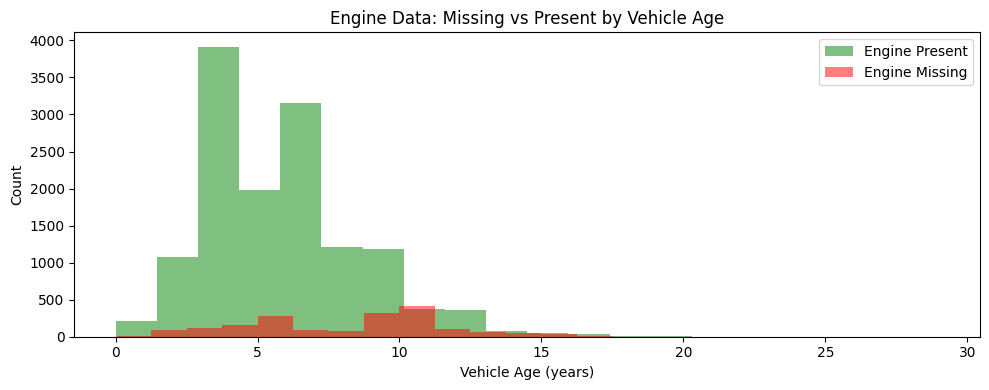

In [19]:
# Is engine missingness related to vehicle age?
engine_missing = df[df['engine'].isna()]['vehicle_age']
engine_present = df[df['engine'].notna()]['vehicle_age']

print(f"Average vehicle age WHERE engine is MISSING: {engine_missing.mean():.1f} years")
print(f"Average vehicle age WHERE engine is PRESENT: {engine_present.mean():.1f} years")

# Visualize it
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(engine_present, bins=20, alpha=0.5, label='Engine Present', color='green')
ax.hist(engine_missing, bins=20, alpha=0.5, label='Engine Missing', color='red')
ax.set_xlabel('Vehicle Age (years)')
ax.set_ylabel('Count')
ax.set_title('Engine Data: Missing vs Present by Vehicle Age')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Older cars have significantly more missing engine data. This is **MAR** (Missing At Random) — the missingness depends on another column (vehicle_age). This makes sense: older car listings often have incomplete specs.

For MAR data, a smarter approach is to impute using **group-wise median** (median engine size per brand or per vehicle_age group) rather than the overall median. But for this session, we'll use the simpler approach and note the advanced option.

### 3.5 — Impute Missing Values

**Choosing between Mean vs Median:**

| Statistic | When to Use | Why |
|---|---|---|
| **Mean** | Data is normally distributed (symmetric) | Represents the "center" well |
| **Median** | Data is skewed or has outliers | Not affected by extreme values |
| **Mode** | Categorical or discrete data | Most common value |

> 💡 **Key Idea**: For car data, most numeric features are **skewed** (a few luxury cars pull the mean way up). So **median is almost always the safer choice** for numeric imputation here.

In [20]:
# Let's see why median > mean for skewed data
print("Engine distribution:")
print(f"  Mean:   {df['engine'].mean():.0f} cc")
print(f"  Median: {df['engine'].median():.0f} cc")
print(f"  Skew:   {df['engine'].skew():.2f}")

print("\nMax Power distribution:")
print(f"  Mean:   {df['max_power'].mean():.1f} bhp")
print(f"  Median: {df['max_power'].median():.1f} bhp")
print(f"  Skew:   {df['max_power'].skew():.2f}")

# Positive skew = right-skewed = mean > median = use median

Engine distribution:
  Mean:   1480 cc
  Median: 1248 cc
  Skew:   1.66

Max Power distribution:
  Mean:   100.5 bhp
  Median: 88.5 bhp
  Skew:   2.51


In [21]:
# Impute numeric columns with MEDIAN
for col in ['engine', 'mileage', 'max_power']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} missing values with median: {median_val}")

# Impute seats with MODE (most common value — it's discrete, not continuous)
seats_mode = df['seats'].mode()[0]
df['seats'] = df['seats'].fillna(seats_mode)
print(f"Filled seats missing values with mode: {seats_mode}")

# Verify: no more missing values
print(f"\nRemaining missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
if df.isnull().sum().sum() == 0:
    print("\n✅ No missing values remaining!")

Filled engine missing values with median: 1248.0
Filled mileage missing values with median: 19.67
Filled max_power missing values with median: 88.5
Filled seats missing values with mode: 5.0

Remaining missing values:
Series([], dtype: int64)

✅ No missing values remaining!


> ⚠️ **Common Mistakes — Missing Values**
> 1. **Imputing the target variable** — Never do this. If `selling_price` is missing, drop that row. You can't predict what you don't know.
> 2. **Using mean on skewed data** — If a few luxury cars have 5000cc engines, the mean gets pulled up. Median is robust to outliers.
> 3. **Imputing BEFORE cleaning text** — If "Petrol" and "petrol" are separate, your group-wise imputation will be wrong.
> 4. **Forgetting to check WHY data is missing** — MCAR, MAR, and MNAR need different strategies. Don't just blindly fill with median.
> 5. **Using `.fillna(0)`** — Zero is a real value! A car with 0 mileage or 0 engine cc is nonsensical. Use mean/median/mode instead.

---

## Step 4: Remove Duplicates

> 🔗 **Connection**: We've fixed text issues and handled missing values. Now let's remove duplicate rows. Why after imputation? Because two rows that looked different (one had NaN, one had a value) might now be identical after imputation.

### 4.1 — What Are Duplicates and Why Do They Matter?

**What:** Two or more rows with identical values in every column.

**Why they're bad for ML:**
- They **bias your model** — the model sees the same data point multiple times and gives it more weight
- They **inflate your metrics** — if a duplicate ends up in both train and test sets, your accuracy looks better than it really is
- They **waste memory and computation**

**Where do duplicates come from?**
- Data scraped from websites (same listing appears multiple times)
- Database joins gone wrong
- Manual data entry errors
- Merging datasets without deduplication

In [22]:
# Check for duplicates
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Total rows before: {len(df)}")

# Remove duplicates
df = df.drop_duplicates()

print(f"Total rows after: {len(df)}")
print(f"Rows removed: {df.duplicated().sum()} remaining duplicates")

Exact duplicate rows: 301
Total rows before: 15503
Total rows after: 15202
Rows removed: 0 remaining duplicates


### 4.2 — Near-Duplicates (Advanced)

Sometimes rows aren't *exactly* identical but are clearly the same car — same brand, model, year, but slightly different km_driven (maybe the listing was updated). These are **near-duplicates**.

> 📝 **Note**: Detecting near-duplicates is harder and often requires domain knowledge. For now, we'll focus on exact duplicates. In practice, you might check for rows where `car_name`, `brand`, `model`, `vehicle_age`, and `fuel_type` all match but `km_driven` differs by less than 1000 km.

> ⚠️ **Common Mistakes — Duplicates**
> 1. **Not checking for duplicates at all** — Always run `df.duplicated().sum()` as part of your initial exploration
> 2. **Removing duplicates too aggressively** — Two different Maruti Altos with the same specs CAN legitimately exist. Only remove if you're sure they're data errors.
> 3. **Checking duplicates before cleaning text** — "Maruti" and " Maruti" look different to `.duplicated()`, so clean text first

---

## Step 5: Handle Outliers

> 🔗 **Connection**: Our data is now clean (no missing values, no duplicates, text is standardized). But some values are clearly wrong — a car selling for ₹99,99,99,999 or ₹500? These outliers will wreck our model if we don't handle them.

### 5.1 — What Are Outliers?

**Outliers** are data points that are significantly different from the rest. They can be:

| Type | Example | Action |
|---|---|---|
| **Data entry errors** | Price = 999999999 (someone typed 9s) | Remove — it's wrong |
| **Genuine extreme values** | A Lamborghini selling for ₹3.9 crore | Keep — it's real, just rare |
| **Measurement errors** | Mileage = 0 kmpl | Investigate — might be electric or error |

The key question: **Is this value wrong, or just unusual?**

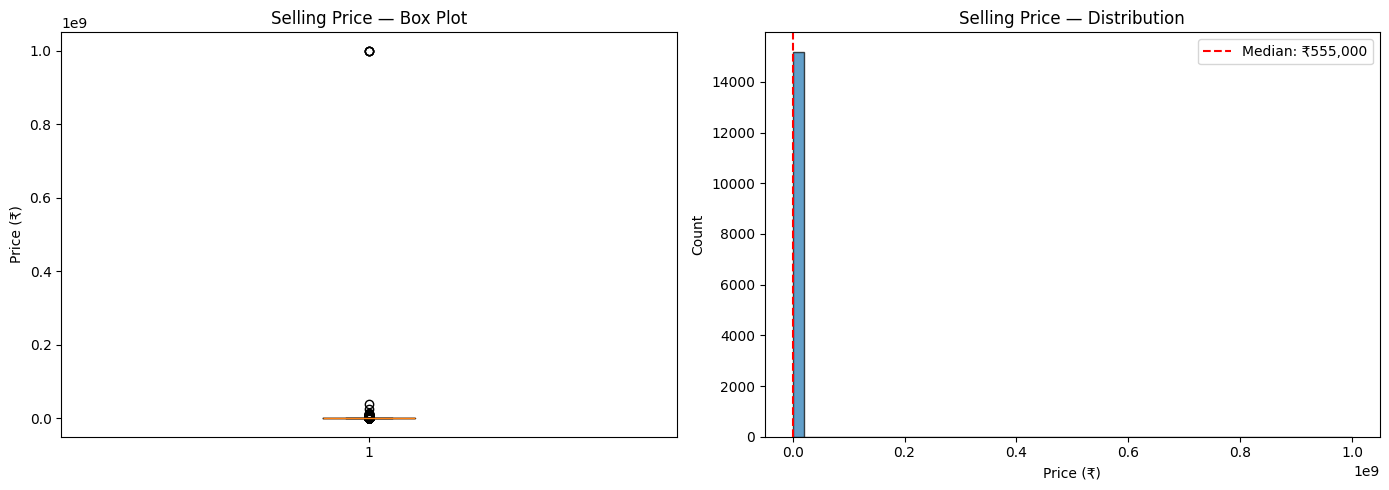

Clearly wrong values:
  Prices = 999999999: 4 rows
  Prices < 1000: 4 rows


In [23]:
# Visualize outliers in selling_price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price — Box Plot')
axes[0].set_ylabel('Price (₹)')

# Histogram
axes[1].hist(df['selling_price'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Selling Price — Distribution')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=df['selling_price'].median(), color='red', linestyle='--', label=f"Median: ₹{df['selling_price'].median():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# The obvious errors
print("Clearly wrong values:")
print(f"  Prices = 999999999: {(df['selling_price'] == 999999999).sum()} rows")
print(f"  Prices < 1000: {(df['selling_price'] < 1000).sum()} rows")

### 5.2 — Removing Obvious Errors

In [24]:
# Remove clearly erroneous prices
before = len(df)

# Remove the 999999999 entries (data entry errors)
df = df[df['selling_price'] != 999999999]

# Remove suspiciously low prices (< ₹10,000 for a car is not realistic)
df = df[df['selling_price'] >= 10000]

# Also fix seats = 0 (impossible)
df = df[df['seats'] > 0]

after = len(df)
print(f"Removed {before - after} rows with impossible values")
print(f"Remaining rows: {after}")

Removed 10 rows with impossible values
Remaining rows: 15192


> 📝 **Note**: We're only removing values that are clearly **wrong** (data entry errors). We're NOT removing expensive cars just because they're expensive — a BMW selling for ₹35 lakh is unusual but real. Removing genuine data points is a common beginner mistake.

> 🧪 **Try It**: Check if there are any cars with `km_driven = 0` or `vehicle_age = 0` but high km_driven. Do these make sense?

---

## ☕ Break Time (5-10 minutes)

We've done the hard part — cleaning. After the break, we'll transform the data for ML: encoding categories and scaling numbers.

---

## Step 6: Encode Categorical Variables

> 🔗 **Connection**: Our data is clean now — no missing values, no duplicates, no typos. But there's a problem: **ML models only understand numbers**. They can't process "Petrol", "Diesel", or "Maruti" directly. We need to convert these text categories into numbers. This is called **encoding**.

### 6.1 — Why Can't ML Models Read Text?

Under the hood, every ML model does math — multiplying weights, computing distances, finding patterns in numbers. When you feed it "Petrol", it doesn't know what to do.

```
Model sees: brand = "Maruti", fuel = "Diesel", transmission = "Manual"
Model needs: brand = ???, fuel = ???, transmission = ???
```

We need a translation system. But here's the catch — **how you translate matters a lot**.

### 6.2 — The Three Encoding Methods

| Method | What It Does | When to Use | Example |
|---|---|---|---|
| **Label Encoding** | Assigns a number to each category (0, 1, 2...) | Binary (2 values) or Ordinal (has natural order) | Manual=0, Automatic=1 |
| **One-Hot Encoding** | Creates a new column for each category (0 or 1) | Nominal (no order) with few categories | fuel_Petrol=1, fuel_Diesel=0, fuel_CNG=0 |
| **Target/Frequency Encoding** | Replaces category with a statistic | High cardinality (many categories) | brand → average price of that brand |

### 6.3 — Label Encoding: For Binary & Ordinal Data

**What:** Assign a number to each category.

**When:** The column has only 2 values (binary) OR the categories have a natural order (ordinal).

**Why not use it for everything?** Because if you encode fuel_type as Petrol=0, Diesel=1, CNG=2, LPG=3, Electric=4 — the model thinks Electric > LPG > CNG > Diesel > Petrol. It thinks there's an ORDER and a DISTANCE between them. But there isn't! Petrol isn't "less than" Diesel.

In [25]:
# Label Encoding for BINARY column: transmission_type (Manual/Automatic)
# This is safe because there are only 2 values — no false ordering issue

print("Before encoding:")
print(df['transmission_type'].value_counts())

# Method 1: Simple map (recommended for binary)
df['transmission_type'] = df['transmission_type'].map({'Manual': 0, 'Automatic': 1})

print("\nAfter encoding:")
print(df['transmission_type'].value_counts())

Before encoding:
transmission_type
Manual       12044
Automatic     3148
Name: count, dtype: int64

After encoding:
transmission_type
0    12044
1     3148
Name: count, dtype: int64


**Why is Label Encoding safe here?** Because with only 2 values, there's no false ordering problem. 0 and 1 is just "this or that" — the model doesn't think 1 > 0 in a meaningful way for binary features.

> ⚠️ **Common Mistakes — Label Encoding**
> 1. **Using Label Encoding on nominal categories with 3+ values** — If you encode fuel_type as 0,1,2,3,4, the model thinks there's an order. Use One-Hot instead.
> 2. **Forgetting that Label Encoding creates a false numeric relationship** — The model will compute distances: |Petrol - Electric| = |0 - 4| = 4. That's meaningless.

### 6.4 — One-Hot Encoding: For Nominal Categories

**What:** Create a new binary column (0/1) for each category.

**When:** The column has no natural order (nominal) and has a manageable number of unique values (< ~10-15).

**The Dummy Variable Trap:** If you have N categories, you only need N-1 columns. Why? Because if fuel_Diesel=0, fuel_CNG=0, fuel_LPG=0, fuel_Electric=0, then it MUST be Petrol. The last column is redundant — and redundant features confuse some models.

```
Original:          One-Hot (with drop_first=True):
fuel_type           fuel_Diesel  fuel_CNG  fuel_LPG  fuel_Electric
─────────           ──────────   ────────  ────────  ─────────────
Petrol         →        0           0         0           0         ← "all zeros" = Petrol
Diesel         →        1           0         0           0
CNG            →        0           1         0           0
LPG            →        0           0         1           0
Electric       →        0           0         0           1
```

In [26]:
# One-Hot Encoding for fuel_type and seller_type
# These are nominal (no order) with few categories

print("Columns BEFORE one-hot encoding:", df.shape[1])
print(f"fuel_type categories: {df['fuel_type'].nunique()} → {df['fuel_type'].unique()}")
print(f"seller_type categories: {df['seller_type'].nunique()} → {df['seller_type'].unique()}")

# Use pd.get_dummies with drop_first=True to avoid the dummy variable trap
df = pd.get_dummies(df, columns=['fuel_type', 'seller_type'], drop_first=True)

print(f"\nColumns AFTER one-hot encoding: {df.shape[1]}")
print("\nNew columns created:")
new_cols = [col for col in df.columns if 'fuel_type_' in col or 'seller_type_' in col]
for col in new_cols:
    print(f"  {col}: {df[col].sum()} rows = 1")

Columns BEFORE one-hot encoding: 13
fuel_type categories: 5 → ['Diesel' 'Cng' 'Petrol' 'Lpg' 'Electric']
seller_type categories: 3 → ['Dealer' 'Individual' 'Trustmark Dealer']

Columns AFTER one-hot encoding: 17

New columns created:
  fuel_type_Diesel: 7307 rows = 1
  fuel_type_Electric: 4 rows = 1
  fuel_type_Lpg: 44 rows = 1
  fuel_type_Petrol: 7543 rows = 1
  seller_type_Individual: 5606 rows = 1
  seller_type_Trustmark Dealer: 170 rows = 1


### 6.5 — Handling High Cardinality: The `brand` Problem

**The Problem:** `brand` has 32 unique values. If we one-hot encode it, we get 31 new columns. That's a lot of sparse columns, and many brands have very few cars (< 50 rows). This can hurt model performance.

**Solutions for high cardinality:**

| Approach | How | Pros | Cons |
|---|---|---|---|
| **Group rare categories** | Combine brands with < N cars into "Other" | Reduces columns | Loses some info |
| **Frequency Encoding** | Replace brand with its count/frequency | 1 column, no sparsity | Loses category identity |
| **Target Encoding** | Replace brand with average target value | Very informative | Risk of data leakage |
| **Just One-Hot it** | Create 31 columns | Simple, no info loss | Many sparse columns |

Let's use the **group rare + one-hot** approach:

In [27]:
# Step 1: See the distribution of brands
brand_counts = df['brand'].value_counts()
print("Brand distribution:")
print(brand_counts)
print(f"\nBrands with < 100 cars: {(brand_counts < 100).sum()}")

Brand distribution:
brand
Maruti           4917
Hyundai          2945
Honda            1465
Mahindra          991
Toyota            790
Ford              774
Volkswagen        610
Renault           524
BMW               434
Tata              423
Skoda             331
Mercedes-Benz     331
Audi              190
Datsun            168
Jaguar             59
Land Rover         50
Jeep               42
Kia                32
Porsche            22
Volvo              20
MG                 19
Mini               17
Nissan             10
Lexus               9
Isuzu               8
Bentley             3
Maserati            2
ISUZU               2
Mercedes-AMG        1
Ferrari             1
Force               1
Rolls-Royce         1
Name: count, dtype: int64

Brands with < 100 cars: 18


In [28]:
# Step 2: Group rare brands (< 100 cars) into "Other"
rare_brands = brand_counts[brand_counts < 100].index.tolist()
print(f"Grouping {len(rare_brands)} rare brands into 'Other': {rare_brands}")

df['brand'] = df['brand'].replace(rare_brands, 'Other')

print(f"\nBrand distribution after grouping:")
print(df['brand'].value_counts())

Grouping 18 rare brands into 'Other': ['Jaguar', 'Land Rover', 'Jeep', 'Kia', 'Porsche', 'Volvo', 'MG', 'Mini', 'Nissan', 'Lexus', 'Isuzu', 'Bentley', 'Maserati', 'ISUZU', 'Mercedes-AMG', 'Ferrari', 'Force', 'Rolls-Royce']

Brand distribution after grouping:
brand
Maruti           4917
Hyundai          2945
Honda            1465
Mahindra          991
Toyota            790
Ford              774
Volkswagen        610
Renault           524
BMW               434
Tata              423
Skoda             331
Mercedes-Benz     331
Other             299
Audi              190
Datsun            168
Name: count, dtype: int64


In [29]:
# Step 3: One-hot encode the cleaned brand column
df = pd.get_dummies(df, columns=['brand'], drop_first=True)

print(f"Total columns after all encoding: {df.shape[1]}")
brand_cols = [col for col in df.columns if 'brand_' in col]
print(f"Brand columns created: {len(brand_cols)}")

Total columns after all encoding: 30
Brand columns created: 14


### 6.6 — Drop Columns We Don't Need for ML

Some columns are informational but not useful as features:

In [30]:
# car_name and model are text descriptions — not useful as features
# (brand already captures the key info, and model has too many unique values)
df = df.drop(columns=['car_name', 'model'], errors='ignore')

print(f"Final shape after encoding and dropping: {df.shape}")
print(f"\nAll columns:")
print(df.columns.tolist())

Final shape after encoding and dropping: (15192, 28)

All columns:
['vehicle_age', 'km_driven', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_Lpg', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'brand_BMW', 'brand_Datsun', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Other', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen']


> ⚠️ **Common Mistakes — Encoding**
> 1. **Label encoding nominal categories** — "Petrol"=0, "Diesel"=1, "CNG"=2 creates a false order. Use One-Hot for nominal data.
> 2. **Forgetting `drop_first=True`** — Creates redundant columns (dummy variable trap). Some models (like Linear Regression) will break.
> 3. **One-hot encoding high cardinality columns directly** — 32 brands → 31 sparse columns. Group rare categories first.
> 4. **Encoding BEFORE cleaning text** — "Petrol" and "petrol" become separate dummy columns. Always clean first.
> 5. **Including ID or name columns as features** — `car_name` is not a feature, it's an identifier. Drop it.

---

## Step 7: Scale & Normalize Numerical Features

> 🔗 **Connection**: All our data is now numeric — categories are encoded, text is gone. But look at the ranges:
> - `km_driven`: 100 to 3,800,000
> - `engine`: 793 to 6,592
> - `vehicle_age`: 0 to 29
> - `selling_price`: 40,000 to 39,500,000
>
> These wildly different scales are a problem for many ML models. A model using distance (like KNN) would think `km_driven` is the most important feature just because its numbers are biggest. We need to put all features on the same scale.

### 7.1 — Why Scale? The Distance Problem

Imagine you're comparing two cars:

```
Car A: km_driven = 50,000    engine = 1200cc    age = 5 years
Car B: km_driven = 51,000    engine = 2000cc    age = 3 years
```

If a model computes distance (like KNN does):
```
Distance = √((51000-50000)² + (2000-1200)² + (3-5)²)
         = √(1000² + 800² + 2²)
         = √(1,000,000 + 640,000 + 4)
         = √1,640,004
```

The `km_driven` difference (1000²) completely dominates. The `age` difference (2²) is invisible. The model thinks km_driven is 500x more important than age — but that's just because of the scale, not because it's actually more important.

**Scaling fixes this by putting all features on a comparable range.**

### 7.2 — The Two Main Scaling Methods

| Method | Formula | Output Range | Best For | Code |
|---|---|---|---|---|
| **StandardScaler** | (x - mean) / std | mean=0, std=1 (roughly -3 to +3) | Most ML models (Linear Reg, SVM, Neural Nets) | `StandardScaler()` |
| **MinMaxScaler** | (x - min) / (max - min) | 0 to 1 | Neural networks, image data, when you need bounded values | `MinMaxScaler()` |

**Which one to use?**
- **Default choice:** StandardScaler (works well for most cases)
- **Use MinMaxScaler when:** you need values between 0 and 1 (neural nets, some distance-based models)
- **Neither needed for:** Decision Trees, Random Forest, XGBoost (tree-based models don't care about scale)

```
Which models NEED scaling?          Which models DON'T?
─────────────────────────           ────────────────────
✅ Linear Regression                ❌ Decision Trees
✅ Logistic Regression              ❌ Random Forest
✅ KNN                              ❌ XGBoost / LightGBM
✅ SVM                              ❌ Naive Bayes
✅ Neural Networks
✅ PCA / K-Means
```

### 7.3 — The Critical Rule: Split BEFORE Scaling

> 💡 **Key Idea — Data Leakage**: You MUST split your data into train and test BEFORE scaling. If you scale first, the scaler learns the mean and std from ALL data (including test). This means your test set has "leaked" information into the training process. Your model's accuracy will look better than it really is.

```
❌ WRONG ORDER (Data Leakage):
Scale ALL data → Split into train/test → Train model

✅ CORRECT ORDER:
Split into train/test → Fit scaler on TRAIN only → Transform both train and test
```

Think of it like a school exam:
- The **training set** is your study material
- The **test set** is the exam paper
- **Scaling on all data** is like seeing the exam questions while studying — your score looks great but it's cheating
- **Scaling on train only** is fair — you study from your material, then face the exam honestly

In [34]:
!pip3 install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 10.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 9.0 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Step 1: Separate features (X) and target (y)
X = df.drop(columns=['selling_price'])
y = df['selling_price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Step 2: Split FIRST (before any scaling!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Features shape: (15192, 27)
Target shape: (15192,)

Train set: 12153 rows
Test set: 3039 rows


In [36]:
# Step 3: Identify which columns need scaling
# Only scale NUMERIC columns — one-hot encoded columns are already 0/1
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

print("Numeric columns to scale:")
print(X_train[numeric_cols].describe().round(1))
print("\nNotice the wildly different ranges — this is why we need scaling!")

Numeric columns to scale:
       vehicle_age  km_driven  mileage   engine  max_power    seats
count      12153.0    12153.0  12153.0  12153.0    12153.0  12153.0
mean           6.0    55730.0     19.7   1451.6       99.9      5.3
std            3.0    55298.1      4.0    483.9       41.3      0.8
min            0.0      100.0      7.5    793.0       38.4      2.0
25%            4.0    30000.0     17.1   1197.0       74.0      5.0
50%            6.0    50000.0     19.7   1248.0       88.5      5.0
75%            8.0    70000.0     22.3   1498.0      116.3      5.0
max           25.0  3800000.0     33.5   5998.0      626.0      9.0

Notice the wildly different ranges — this is why we need scaling!


In [37]:
# Step 4: Fit scaler on TRAIN data only, then transform both
scaler = StandardScaler()

# fit_transform on train (learns mean/std from train, then transforms)
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# transform on test (uses the mean/std learned from train — NO fitting!)
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("After StandardScaler (train set):")
print(X_train[numeric_cols].describe().round(2))
print("\n✅ All numeric features now have mean ≈ 0 and std ≈ 1")

After StandardScaler (train set):
       vehicle_age  km_driven   mileage    engine  max_power     seats
count     12153.00   12153.00  12153.00  12153.00   12153.00  12153.00
mean         -0.00       0.00     -0.00      0.00       0.00      0.00
std           1.00       1.00      1.00      1.00       1.00      1.00
min          -2.01      -1.01     -3.06     -1.36      -1.49     -4.19
25%          -0.68      -0.47     -0.65     -0.53      -0.63     -0.40
50%          -0.01      -0.10     -0.01     -0.42      -0.28     -0.40
75%           0.66       0.26      0.66      0.10       0.40     -0.40
max           6.33      67.71      3.47      9.40      12.72      4.66

✅ All numeric features now have mean ≈ 0 and std ≈ 1


### 7.4 — Comparing Before vs After Scaling

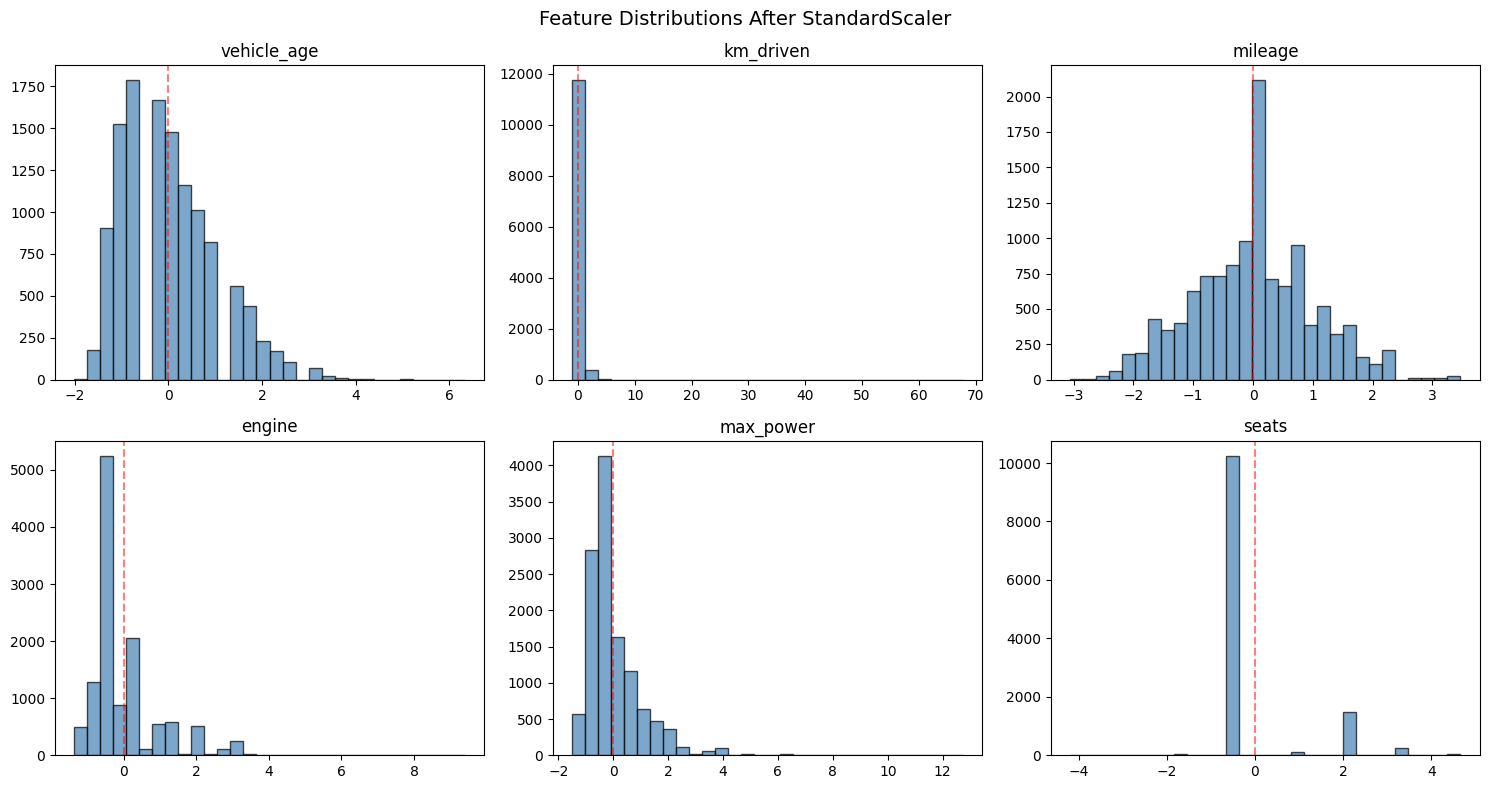

In [38]:
# Visual comparison: before vs after scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions After StandardScaler', fontsize=14)

for i, col in enumerate(numeric_cols):
    row, col_idx = i // 3, i % 3
    axes[row][col_idx].hist(X_train[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[row][col_idx].set_title(col)
    axes[row][col_idx].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

> ⚠️ **Common Mistakes — Scaling**
> 1. **Scaling before splitting** — This is DATA LEAKAGE. The scaler sees test data during fitting. Always split first.
> 2. **Using `fit_transform` on test data** — Use `scaler.transform(X_test)` only. `fit_transform` would learn new mean/std from test data.
> 3. **Scaling the target variable** — Don't scale `selling_price`. The model should predict actual prices, not scaled values. (Exception: some neural net architectures benefit from scaled targets, but that's advanced.)
> 4. **Scaling one-hot encoded columns** — They're already 0 and 1. Scaling them is unnecessary and can actually hurt interpretability.
> 5. **Forgetting to scale at prediction time** — When you get new data to predict, you must scale it using the SAME scaler (with the same mean/std from training).

### 7.5 — StandardScaler vs MinMaxScaler: Side by Side

In [39]:
# Let's compare both scalers on the same data
# Using a fresh copy of km_driven from training data for demonstration

sample_data = X_train[['km_driven']].copy()

# StandardScaler (already applied, but let's show both)
ss = StandardScaler()
minmax = MinMaxScaler()

ss_result = ss.fit_transform(sample_data)
mm_result = minmax.fit_transform(sample_data)

comparison = pd.DataFrame({
    'Original': sample_data['km_driven'].describe(),
    'StandardScaler': pd.Series(ss_result.flatten()).describe(),
    'MinMaxScaler': pd.Series(mm_result.flatten()).describe()
}).round(3)

print("Comparison of Scaling Methods:")
print(comparison)

Comparison of Scaling Methods:
        Original  StandardScaler  MinMaxScaler
count  12153.000       12153.000     12153.000
mean       0.000           0.000         0.015
std        1.000           1.000         0.015
min       -1.006          -1.006         0.000
25%       -0.465          -0.465         0.008
50%       -0.104          -0.104         0.013
75%        0.258           0.258         0.018
max       67.713          67.713         1.000


---

## Step 8: Final Sanity Check

Before we declare the data ML-ready, let's verify everything:

In [40]:
print("=" * 60)
print("FINAL DATA QUALITY CHECK")
print("=" * 60)

print(f"\n1. Shape: {X_train.shape[0]} train rows, {X_test.shape[0]} test rows, {X_train.shape[1]} features")

print(f"\n2. Missing values in train: {X_train.isnull().sum().sum()}")
print(f"   Missing values in test: {X_test.isnull().sum().sum()}")

print(f"\n3. Data types:")
print(f"   Numeric: {X_train.select_dtypes(include='number').shape[1]} columns")
print(f"   Non-numeric: {X_train.select_dtypes(exclude='number').shape[1]} columns")

print(f"\n4. Target variable (selling_price):")
print(f"   Train — Mean: ₹{y_train.mean():,.0f}, Median: ₹{y_train.median():,.0f}")
print(f"   Test  — Mean: ₹{y_test.mean():,.0f}, Median: ₹{y_test.median():,.0f}")

print(f"\n5. Numeric features scaled: {numeric_cols}")
print(f"   Train mean ≈ 0? {X_train[numeric_cols].mean().abs().max() < 0.01}")
print(f"   Train std ≈ 1? {(X_train[numeric_cols].std() - 1).abs().max() < 0.01}")

if X_train.isnull().sum().sum() == 0 and X_train.select_dtypes(exclude='number').shape[1] == 0:
    print("\n✅ DATA IS ML-READY! You can now train a model on this.")
else:
    print("\n❌ Still some issues to fix — check above.")

FINAL DATA QUALITY CHECK

1. Shape: 12153 train rows, 3039 test rows, 27 features

2. Missing values in train: 0
   Missing values in test: 0

3. Data types:
   Numeric: 7 columns
   Non-numeric: 20 columns

4. Target variable (selling_price):
   Train — Mean: ₹774,018, Median: ₹560,000
   Test  — Mean: ₹784,320, Median: ₹550,000

5. Numeric features scaled: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
   Train mean ≈ 0? True
   Train std ≈ 1? True

❌ Still some issues to fix — check above.


---

## The Complete Data Prep Pipeline — Cheat Sheet

```
Raw Messy Data
    │
    ├── Step 1: EXPLORE — df.info(), .describe(), .isnull().sum(), .duplicated().sum()
    │           Check categorical unique values, check dtypes
    │
    ├── Step 2: FIX TEXT — .str.strip(), .str.title(), .replace() for typos
    │           Clean BEFORE encoding or imputing
    │
    ├── Step 3: HANDLE MISSING VALUES
    │           ├── Target missing? → DROP those rows
    │           ├── < 5% missing? → Drop rows OR impute
    │           ├── 5-30% missing? → Impute (median for numeric, mode for categorical)
    │           └── > 30% missing? → Consider dropping the COLUMN
    │
    ├── Step 4: REMOVE DUPLICATES — df.drop_duplicates()
    │
    ├── Step 5: HANDLE OUTLIERS — Remove data entry errors, keep genuine extremes
    │
    ├── Step 6: ENCODE CATEGORIES
    │           ├── Binary (2 values) → Label Encoding (map to 0/1)
    │           ├── Nominal (no order, < 10 categories) → One-Hot (drop_first=True)
    │           └── High cardinality (> 10 categories) → Group rare + One-Hot
    │
    ├── Step 7: SPLIT into train/test (BEFORE scaling!)
    │
    └── Step 8: SCALE NUMERIC FEATURES
                ├── fit_transform on TRAIN
                └── transform on TEST (never fit on test!)
```

### Decision Quick Reference

| Question | Answer |
|---|---|
| Mean or Median for imputation? | Median (safer for skewed data) |
| Label or One-Hot encoding? | Label for binary/ordinal, One-Hot for nominal |
| StandardScaler or MinMaxScaler? | StandardScaler (default), MinMaxScaler for neural nets |
| Scale before or after split? | AFTER split (to avoid data leakage) |
| Scale the target? | No (usually) |
| Scale one-hot columns? | No (already 0/1) |
| Drop or impute missing target? | Always DROP |

---

## Summary

Today we took a real-world messy dataset (15,000+ used car listings) and made it ML-ready:

1. **Explored** the mess — found missing values, duplicates, typos, string pollution, outliers
2. **Fixed text** — standardized casing, fixed typos, stripped whitespace
3. **Handled missing values** — dropped target NaNs, imputed features with median/mode
4. **Removed duplicates** — exact duplicates gone
5. **Handled outliers** — removed data entry errors (₹999999999, ₹500)
6. **Encoded categories** — Label for binary, One-Hot for nominal, grouped rare brands
7. **Scaled features** — StandardScaler on numeric columns, split BEFORE scaling

**Next session (9.3):** We'll use this clean data to train our first regression model and predict used car prices!

---

*The data is clean. The features are ready. Time to build a model.* 🚗💰